## Data Processing for model training.

1. Check and combine test, train data from the WPD so I can use it later.
2. Keep only a subset of the features, based on correlation.
3. Add the timezone-aligned price data to the final dataset. Keep things simple and all in one place!!!

In [99]:
import matplotlib.pyplot as plt
import pandas as pd
from pyprojroot import here
import datetime as dt
import numpy as np
import holidays

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 5)

ROOT_DIR = here()
DATA_DIR = ROOT_DIR / "1_data" / "raw" / "wpd_comp_data_2021"
PROCESSED_PRICE_DATA_DIR = ROOT_DIR / "1_data" / "processed"
SAVED_DIR = ROOT_DIR / "1_data" / "processed"

demand_train = pd.read_csv(DATA_DIR / "demand_train_set4.csv", parse_dates=["datetime"])
demand_test = pd.read_csv(DATA_DIR / "demand_test_set4.csv", parse_dates=["datetime"])
pv_train = pd.read_csv(DATA_DIR / "pv_train_set4.csv", parse_dates=["datetime"])
pv_test = pd.read_csv(DATA_DIR / "pv_test_set4.csv", parse_dates=["datetime"])
weather = pd.read_csv(DATA_DIR / "weather_train_set4.csv", parse_dates=["datetime"])

price = pd.read_csv(PROCESSED_PRICE_DATA_DIR / "gb_price.csv", parse_dates=["datetime"])

#demand_train["split"], demand_test["split"] = "train", "test"
#pv_train["split"], pv_test["split"] = "train", "test"

## EDA showed datasets are cut exatly at the same datetime, so we can just concatenate them and add a split column later if needed.
demand = pd.concat([demand_train, demand_test], ignore_index=True)
pv = pd.concat([pv_train, pv_test], ignore_index=True)

In [100]:
## resample to hourly data

demand_hourly = demand.set_index("datetime").resample("h").mean().reset_index()
pv_hourly = pv.set_index("datetime").resample("h").mean().reset_index()

print(demand_hourly.shape, pv_hourly.shape)
#demand_hourly.head()
pv_hourly.head()

(23520, 2) (23520, 4)


,datetime,irradiance_Wm-2,pv_power_mw,panel_temp_C
0,2017-11-03 00:00:00,0.0,0.0,7.215
1,2017-11-03 01:00:00,0.0,0.0,7.590
2,2017-11-03 02:00:00,0.0,0.0,7.240
3,2017-11-03 03:00:00,0.0,0.0,8.130
4,2017-11-03 04:00:00,0.0,0.0,7.765


In [101]:
pv_hourly[pv_hourly.isna().any(axis=1)]

,datetime,irradiance_Wm-2,pv_power_mw,panel_temp_C
617,2017-11-28 17:00:00,0.0,0.0,NaN
618,2017-11-28 18:00:00,0.0,0.0,NaN
619,2017-11-28 19:00:00,0.0,0.0,NaN
620,2017-11-28 20:00:00,0.0,0.0,NaN
621,2017-11-28 21:00:00,0.0,0.0,NaN
...,...,...,...,...
22014,2020-05-08 06:00:00,NaN,NaN,NaN
22015,2020-05-08 07:00:00,NaN,NaN,NaN
22016,2020-05-08 08:00:00,NaN,NaN,NaN
22017,2020-05-08 09:00:00,NaN,NaN,NaN


In [102]:

# Merge demand, pv, and weather on datetime (which has been shown to be aligned during EDA)


combined = demand.merge(pv, on="datetime").merge(weather, on="datetime")

combined['datetime'] = combined['datetime'].astype('datetime64[ns]')
combined["datetime"] = pd.to_datetime(combined["datetime"], utc=True)

print(f"Combined dataset shape: {combined.shape}")
print(combined.datetime.min(), combined.datetime.max())

## The fact that the data starts at 2021-01-01 00:00:00 and ends at 2021-12-31 23:00:00, further confirms that data is UTC aligned.
# It is the split is clean in UTC 0 and not local time, since the UK is in UTC+0 during winter and UTC+1 during summer.

Combined dataset shape: (23520, 17)
2017-11-03 00:00:00+00:00 2020-07-09 23:00:00+00:00


# Plot some graphs for further EDA

/tmp/ipykernel_327285/2815271528.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


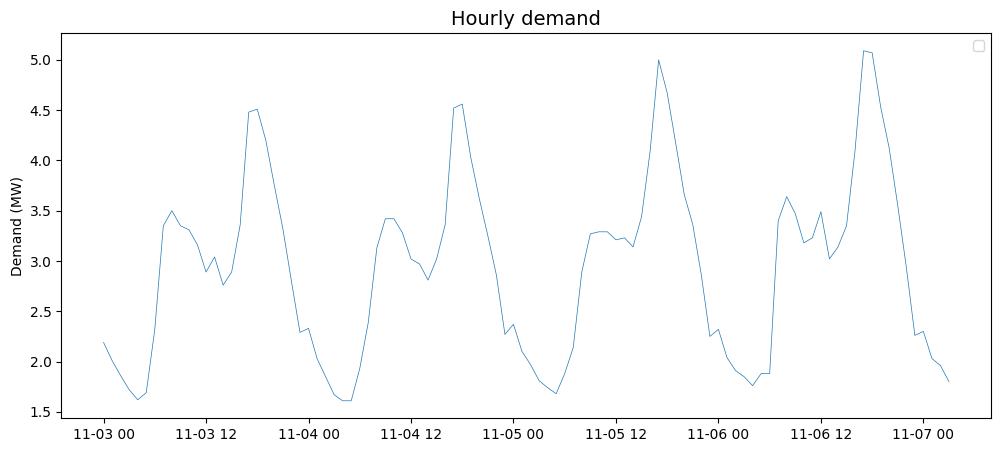

In [103]:
fig, ax = plt.subplots()
ax.plot(combined["datetime"].iloc[:100], combined["demand_MW"].iloc[:100], linewidth=0.5)
ax.set_title("Hourly demand", fontsize=14)
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()

/tmp/ipykernel_327285/3134893626.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


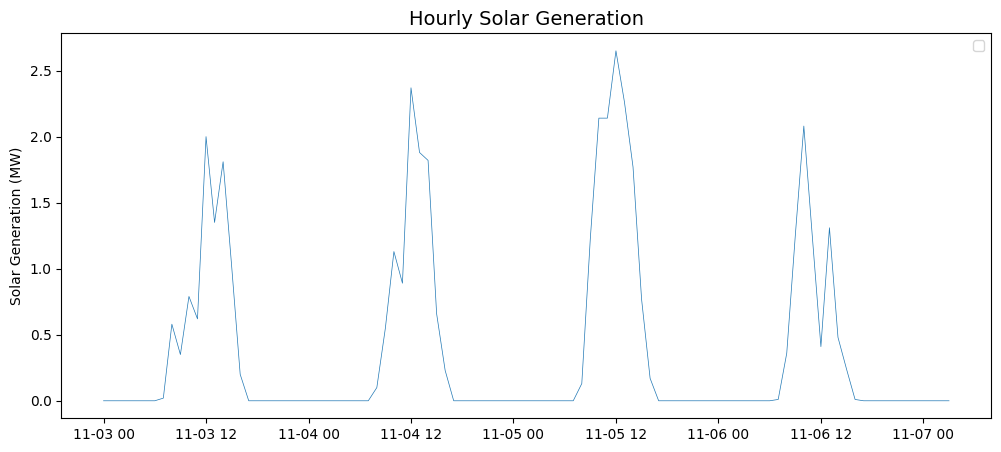

In [104]:
fig, ax = plt.subplots()
ax.plot(combined["datetime"].iloc[:100], combined["pv_power_mw"].iloc[:100], linewidth=0.5)
ax.set_title("Hourly Solar Generation", fontsize=14)
ax.set_ylabel("Solar Generation (MW)")
ax.legend()
plt.show()

/tmp/ipykernel_327285/3458862678.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


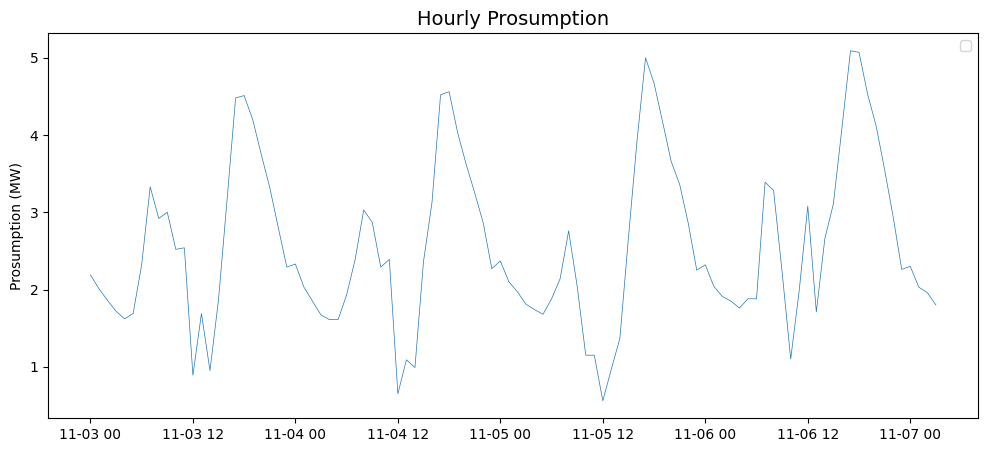

In [105]:
combined["prosumption"] = combined["demand_MW"] - combined["pv_power_mw"]

fig, ax = plt.subplots()
ax.plot(combined["datetime"].iloc[:100], combined["prosumption"].iloc[:100], linewidth=0.5)
ax.set_title("Hourly Prosumption", fontsize=14)
ax.set_ylabel("Prosumption (MW)")
ax.legend()
plt.show()

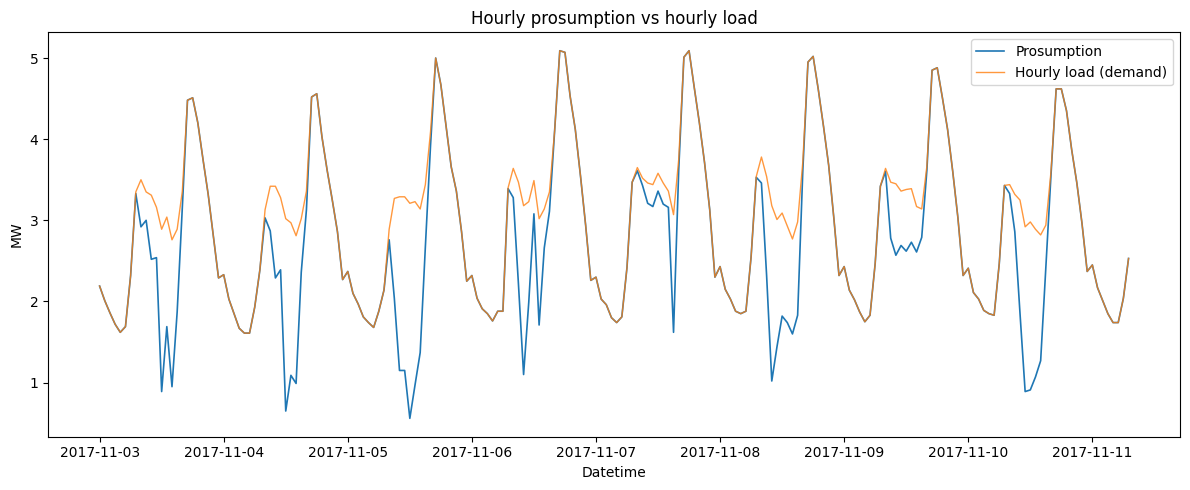

In [106]:
n = min(200, len(combined))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(combined["datetime"].iloc[:n], combined["prosumption"].iloc[:n], label="Prosumption", linewidth=1.2)
ax.plot(combined["datetime"].iloc[:n], combined["demand_MW"].iloc[:n], label="Hourly load (demand)", linewidth=1.0, alpha=0.8)

ax.set_title("Hourly prosumption vs hourly load")
ax.set_xlabel("Datetime")
ax.set_ylabel("MW")
ax.legend()
plt.tight_layout()
plt.show()

## Feature selection

In [107]:
possible_features = combined.columns.difference(["datetime", "demand_MW", "pv_power_mw", "prosumption"])
possible_features

Index(['irradiance_Wm-2', 'panel_temp_C', 'solar_location1', 'solar_location2',
       'solar_location3', 'solar_location4', 'solar_location5',
       'solar_location6', 'temp_location1', 'temp_location2', 'temp_location3',
       'temp_location4', 'temp_location5', 'temp_location6'],
      dtype='str')

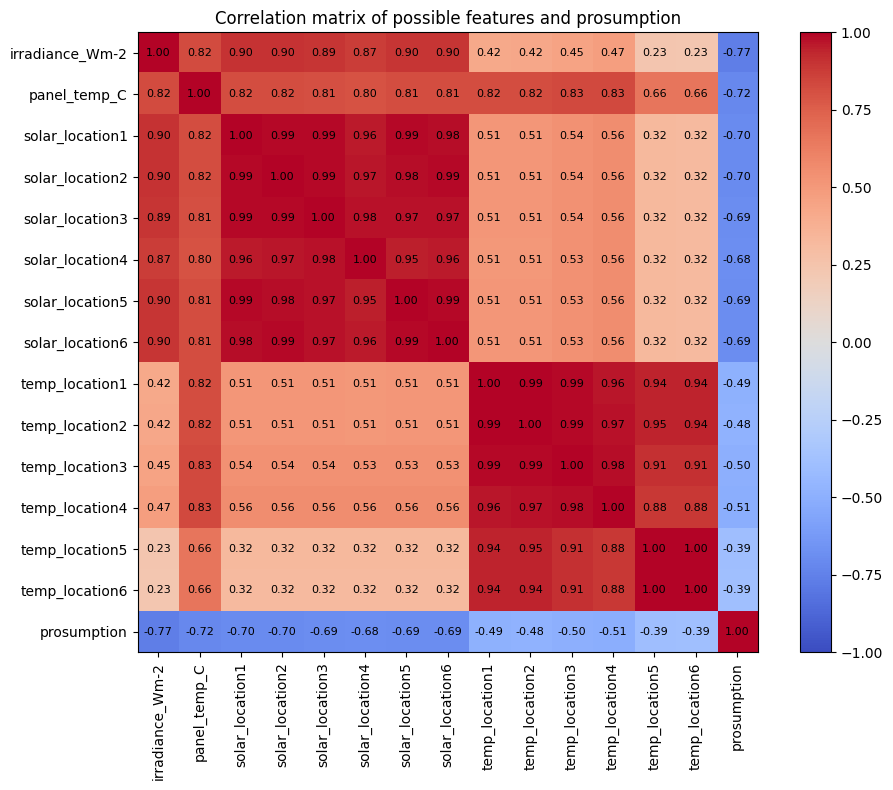

In [108]:
corr_matrix = combined[possible_features.tolist() + ["prosumption"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix)))
ax.set_yticks(range(len(corr_matrix)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title("Correlation matrix of possible features and prosumption")
plt.tight_layout()
plt.show()

In [109]:
corr_matrix["prosumption"].sort_values(ascending=False)

prosumption        1.000000
temp_location6    -0.386456
temp_location5    -0.391959
temp_location2    -0.483952
temp_location1    -0.488139
temp_location3    -0.497508
temp_location4    -0.506518
solar_location4   -0.679898
solar_location5   -0.694127
solar_location6   -0.694202
solar_location3   -0.694902
solar_location1   -0.698584
solar_location2   -0.698587
panel_temp_C      -0.715131
irradiance_Wm-2   -0.765078
Name: prosumption, dtype: float64

In [110]:
combined["datetime"].min(), combined["datetime"].max(), combined.shape

(Timestamp('2017-11-03 00:00:00+0000', tz='UTC'),
 Timestamp('2020-07-09 23:00:00+0000', tz='UTC'),
 (23520, 18))

In [111]:
missing = combined[list(possible_features)].isna().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found in possible_features.")
else:
    print("Missing values in possible_features:")
    print(missing.to_frame(name="missing_count"))

Missing values in possible_features:
                 missing_count
irradiance_Wm-2             45
panel_temp_C                46
solar_location1             72
solar_location2             24
temp_location4              48


# Chosen features:
## Chose solar_location3, panel_temp_C, temp_location3
- Decision made on criteria of correlation with prosumption, data availability and clarity of the variable.
- irradiance wasn't chosen as it isn't clear what the measurement is of / from.
- Solar_radiation is clearer as it is reanalysis of solar radiation data from a weather station.
- panel_temp_C is strongly negatively correlated with prosumption and explainable.
- temp_location3 was chosen over temp_location4 despite slightly lower correlation due to completeness of data.

In [112]:
combined["solar_location3"].describe()

count    23520.000000
mean       142.969852
std        224.168791
min          0.000000
25%          0.000000
50%          3.935000
75%        213.137500
max        934.750000
Name: solar_location3, dtype: float64

In [113]:
# Note on solar_location3
"""
Based on the statistical distribution, this variable is almost certainly Global Horizontal Irradiance (GHI) measured in Watts per square meter (W/m²).
In weather reanalysis datasets (such as ERA5 or MERRA-2), this is often labeled as "surface solar radiation downwards" (SSRD) or similar.
Here is the objective breakdown of why the summary statistics align with GHI:

While it is definitively W/m², it is possible it represents Direct Normal Irradiance (DNI) rather than GHI.
However, GHI is the standard baseline measurement in most weather station and reanalysis datasets used for solar power forecasting.
It is not Diffuse Horizontal Irradiance (DHI), as DHI rarely exceeds 400-500 W/m².
"""

'\nBased on the statistical distribution, this variable is almost certainly Global Horizontal Irradiance (GHI) measured in Watts per square meter (W/m²).\nIn weather reanalysis datasets (such as ERA5 or MERRA-2), this is often labeled as "surface solar radiation downwards" (SSRD) or similar.\nHere is the objective breakdown of why the summary statistics align with GHI:\n\nWhile it is definitively W/m², it is possible it represents Direct Normal Irradiance (DNI) rather than GHI.\nHowever, GHI is the standard baseline measurement in most weather station and reanalysis datasets used for solar power forecasting.\nIt is not Diffuse Horizontal Irradiance (DHI), as DHI rarely exceeds 400-500 W/m².\n'

In [114]:
features = ["solar_location3", "panel_temp_C", "temp_location3"]

rename_dict = {
    "solar_location3": "solar_irrad", 
    "panel_temp_C": "panel_temp",
    "temp_location3": "ambient_temp",

}

df_full = combined[["datetime", "prosumption"] + features].merge(price, on="datetime", how="left")
df_full = df_full.rename(columns=rename_dict)

In [115]:
df_full.index.is_monotonic_increasing

True

In [116]:
df_full.to_csv(SAVED_DIR / "df_full.csv", index=False)

# Extra: Prosumption Analysis

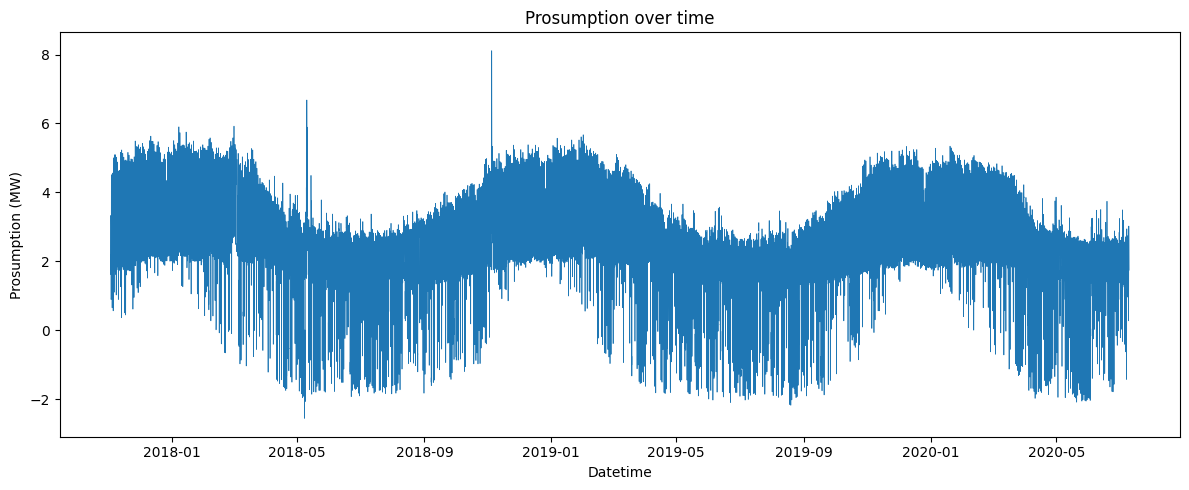

In [117]:
fig, ax = plt.subplots()
ax.plot(combined["datetime"], combined["prosumption"], linewidth=0.5)
ax.set_title("Prosumption over time")
ax.set_xlabel("Datetime")
ax.set_ylabel("Prosumption (MW)")
plt.tight_layout()
plt.show()

In [118]:
summary = []

for year in [2018, 2019, 2020]:
    mask = (
        (combined["datetime"].dt.year == year)
        & (combined["datetime"].dt.month.isin([1, 2, 3, 4, 5, 6]))
    )
    prosumption_values = combined.loc[mask, "prosumption"]
    summary.append(
        {
            "year": year,
            "mean_prosumption": prosumption_values.mean(),
            "std_prosumption": prosumption_values.std(),
            "count": prosumption_values.shape[0],
        }
    )

pd.DataFrame(summary)

,year,mean_prosumption,std_prosumption,count
0,2018,2.333773,1.485861,4344
1,2019,2.159926,1.420786,4344
2,2020,2.040688,1.426893,4368


In [119]:
years = [2018, 2019, 2020]

diurnal_profiles = {}
residual_stats = []
residuals_list = []

for year in years:
    mask = (
        (combined["datetime"].dt.year == year)
        & (combined["datetime"].dt.month <= 6)
    )
    period = combined.loc[mask, ["datetime", "prosumption"]].copy()
    period["hour"] = period["datetime"].dt.hour

    diurnal = period.groupby("hour")["prosumption"].mean()
    diurnal_profiles[year] = diurnal

    period = period.merge(diurnal.rename("diurnal_mean"), on="hour")
    period["residual"] = period["prosumption"] - period["diurnal_mean"]

    residuals_list.append(period)

    residual_stats.append(
        {
            "year": year,
            "count": period.shape[0],
            "residual_std": period["residual"].std(),
        }
    )

residual_summary = pd.DataFrame(residual_stats)
residuals = pd.concat(residuals_list, ignore_index=True)

residual_summary

,year,count,residual_std
0,2018,4344,1.209270
1,2019,4344,1.111956
2,2020,4368,1.148468


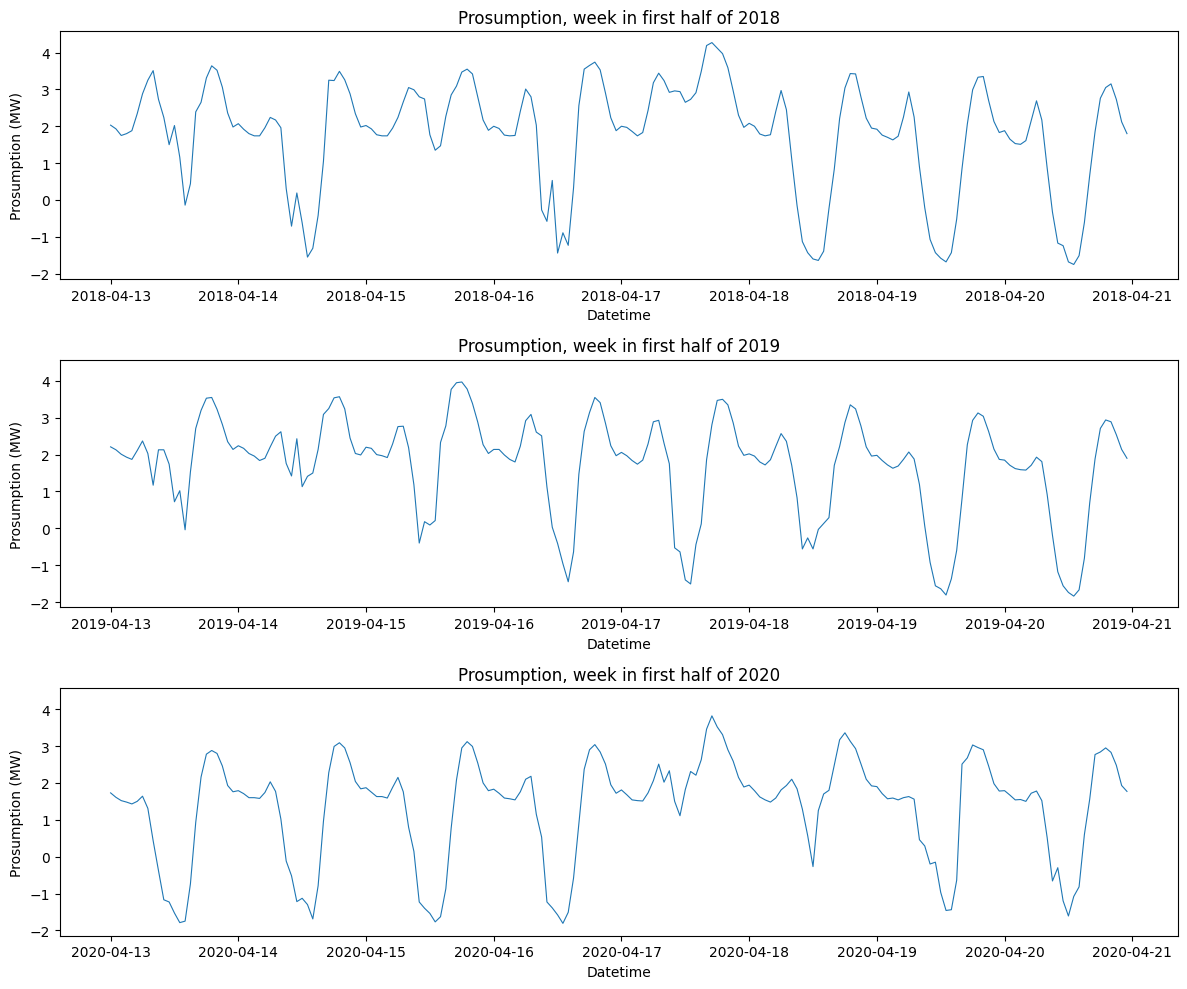

In [120]:
years = [2018, 2019, 2020]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=True)

for year, ax in zip(years, axes):
    start = dt.datetime(year, 4, 13, tzinfo=dt.timezone.utc)
    end = dt.datetime(year, 4, 20, 23, 59, 59, tzinfo=dt.timezone.utc)
    yearly = combined.loc[
        (combined["datetime"] >= start) & (combined["datetime"] <= end),
        ["datetime", "prosumption"]
    ]
    ax.plot(yearly["datetime"], yearly["prosumption"], linewidth=0.8)
    ax.set_title(f"Prosumption, week in first half of {year}")
    ax.set_ylabel("Prosumption (MW)")
    ax.set_xlabel("Datetime")

plt.tight_layout()
plt.show()

In [121]:
months = {
    "before_lockdown_0": ["2018-04", "2018-05"],
    "before_lockdown_1": ["2019-04", "2019-05"],
    "before_lockdown_2": ["2019-06", "2019-07"],
    "before_lockdown_3": ["2019-08", "2019-09"],
    "during_lockdown": ["2020-04", "2020-05"],
    "after_lockdown": ["2020-06", "2020-07"]
}

summary = {}

for label, month_list in months.items():
    month_periods = pd.PeriodIndex(month_list, freq="M")
    mask = combined["datetime"].dt.to_period("M").isin(month_periods)
    summary[label] = combined.loc[mask, "prosumption"].describe()

pd.concat(summary, axis=1)

/tmp/ipykernel_327285/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)
/tmp/ipykernel_327285/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)
/tmp/ipykernel_327285/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)
/tmp/ipykernel_327285/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)
/tmp/ipykernel_327285/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)


,before_lockdown_0,before_lockdown_1,before_lockdown_2,before_lockdown_3,during_lockdown,after_lockdown
count,1464.000000,1464.000000,1462.000000,1464.000000,1458.000000,936.000000
mean,1.745533,1.614665,1.249494,1.453989,1.249191,1.484327
std,1.457513,1.288924,1.262436,1.263346,1.383570,1.055692
min,-2.560000,-1.910000,-2.100000,-2.180000,-2.090000,-2.040000
25%,1.427500,1.260000,0.780000,1.197500,0.540000,1.280000
50%,1.960000,1.860000,1.500000,1.610000,1.590000,1.590000
75%,2.710000,2.450000,2.100000,2.350000,2.150000,2.220000
max,6.680000,4.250000,3.570000,4.020000,3.860000,3.740000


In [122]:
expected_idx = pd.date_range(df_full["datetime"].min(), df_full["datetime"].max(), freq="h")
actual_idx = pd.DatetimeIndex(df_full["datetime"])

missing = expected_idx.difference(actual_idx)
duplicates = df_full[df_full["datetime"].duplicated(keep=False)]

print(f"Expected hourly timestamps: {len(expected_idx)}")
print(f"Actual timestamps in df_full: {len(actual_idx)}")
print(f"Missing timestamps: {len(missing)}")
print(f"Duplicate datetime rows: {duplicates.shape[0]}")

if len(missing):
    print("Missing datetime values:")
    print(missing[:20])
else:
    print("No gaps found in the hourly datetime grid.")

Expected hourly timestamps: 23520
Actual timestamps in df_full: 23520
Missing timestamps: 0
Duplicate datetime rows: 0
No gaps found in the hourly datetime grid.


In [123]:
prosumption = df_full["prosumption"].copy()
prosumption.describe()

count    23501.000000
mean         2.215717
std          1.407456
min         -2.560000
25%          1.580000
50%          2.260000
75%          3.080000
max          8.110000
Name: prosumption, dtype: float64

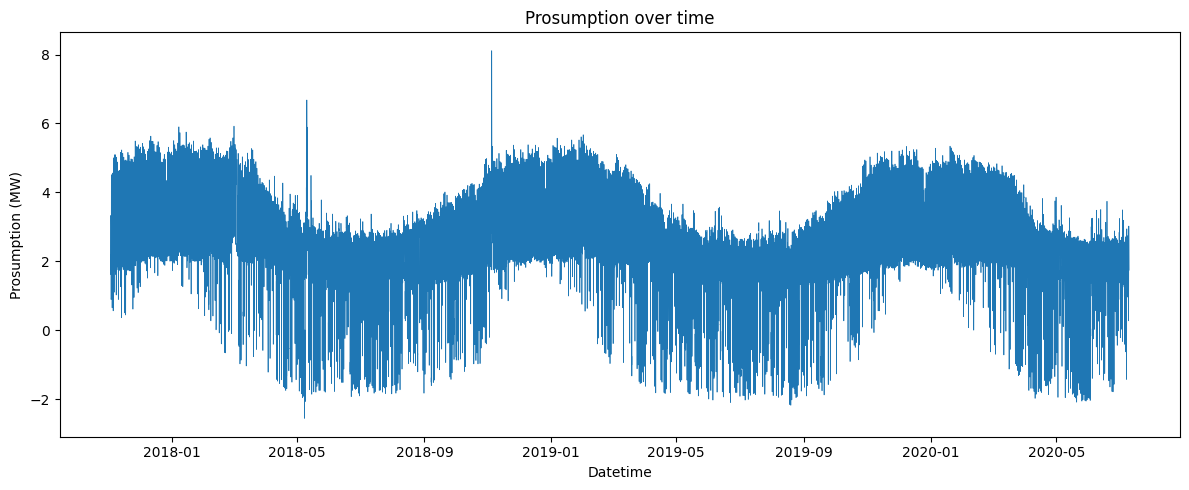

In [124]:
fig, ax = plt.subplots()
ax.plot(df_full["datetime"], df_full["prosumption"], linewidth=0.5)
ax.set_title("Prosumption over time")
ax.set_xlabel("Datetime")
ax.set_ylabel("Prosumption (MW)")
plt.tight_layout()
plt.show()

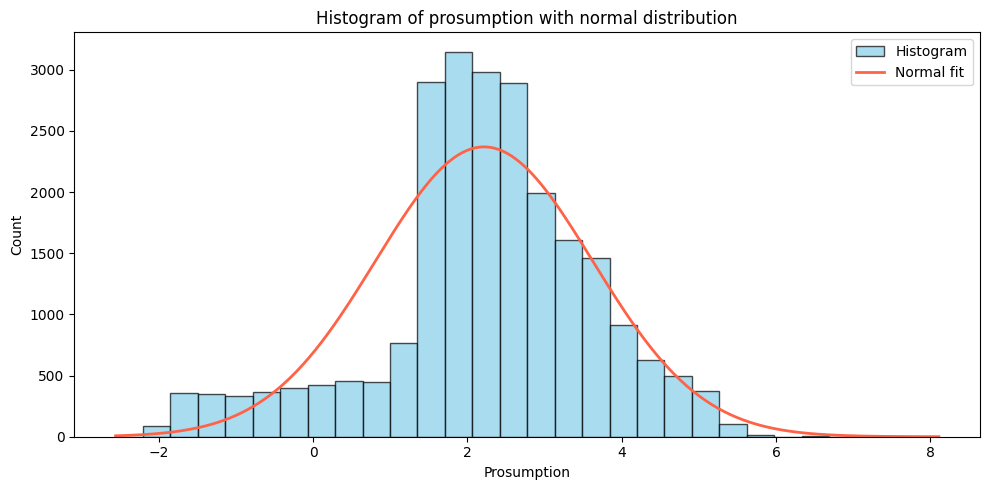

In [125]:
values = prosumption.dropna().astype(float)

mu = values.mean()
sigma = values.std(ddof=0)

fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(
    values,
    bins=30,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="Histogram",
)

bin_width = bins[1] - bins[0]
x = np.linspace(values.min(), values.max(), 400)
y = len(values) * bin_width * (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

ax.plot(x, y, color="tomato", linewidth=2, label="Normal fit")

ax.set_title("Histogram of prosumption with normal distribution")
ax.set_xlabel("Prosumption")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()